# Fast convolution

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np
import scipy as sc

In [2]:
import fitz

In [3]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [4]:
from fast_convolution import toom_cook, g2bg, recursive_log2, log2_lst, log2_matrix

In [5]:
from utils import plot_pdf

In [6]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

Size of vectors

In [7]:
d_num = 4
g_num = 3

Example of vectors for the convolution

In [8]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3, 4] [1, 2, 3]


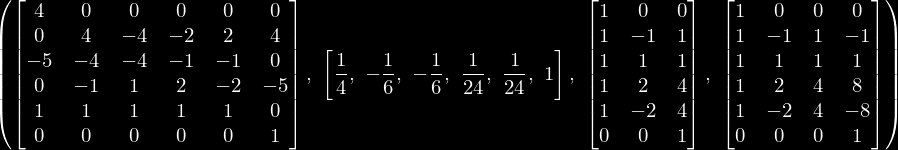

In [19]:
c_mtx, cq, b_mtx, a_mtx = toom_cook(d_num, g_num, [0, -1, 1, 2, -2, np.inf])
c_mtx, cq, b_mtx, a_mtx

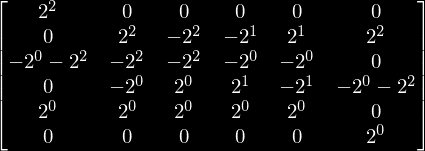

In [22]:
log2_matrix(log2_lst(c_mtx))

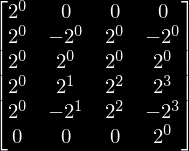

In [23]:
log2_matrix(log2_lst(a_mtx))

In [13]:
bg_mtx = g2bg(cq, b_mtx, g_values)

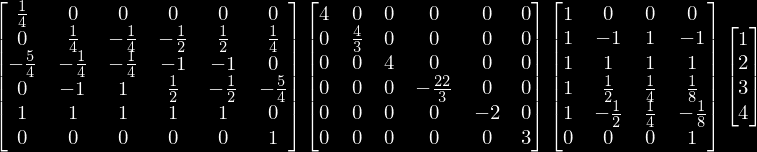

In [14]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d_values))
s

Comparing numerical outputs from direct and winograd method

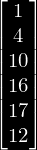

In [15]:
sy.Matrix(np.convolve(d_values, g_values))

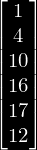

In [16]:
sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d_values), evaluate=True)